LAB 7

**Dataset Aleatorio**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random
#Generamos los centroides
n_centers = random.randint(1, 20)
print(f"Número de centroides a generar: {n_centers}")
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-30, 30, size=2)
    if all(np.linalg.norm(candidate - c) > 6 for c in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 0.8)

X, y = make_blobs(n_samples=2000,
                  centers=blob_centers,
                  cluster_std=blob_std,
                  random_state=42)

print(f"Se generaron {n_centers} centroides")
print(f"Total de muestras: {X.shape[0]}")
print("Coordenadas de los centroides:")
print(blob_centers)

Número de centroides a generar: 15
Se generaron 15 centroides
Total de muestras: 2000
Coordenadas de los centroides:
[[  9.7482469   16.8436861 ]
 [  0.75663204  26.16538152]
 [-14.85294882  15.59592603]
 [  5.88254506 -19.05757211]
 [  9.77546023  27.1095921 ]
 [ 26.15056234  25.96231603]
 [-23.48737099  -9.80224987]
 [-27.88254996  21.55880682]
 [ -8.58832968 -17.84032849]
 [ 21.25280747  18.09463133]
 [  2.94068269 -29.22719155]
 [-12.20418274   9.78425021]
 [  5.21740127  -0.32203646]
 [-11.68290875  -0.85598747]
 [-11.35385579  26.51325765]]


In [3]:
#Visualizar y plot_clusters
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

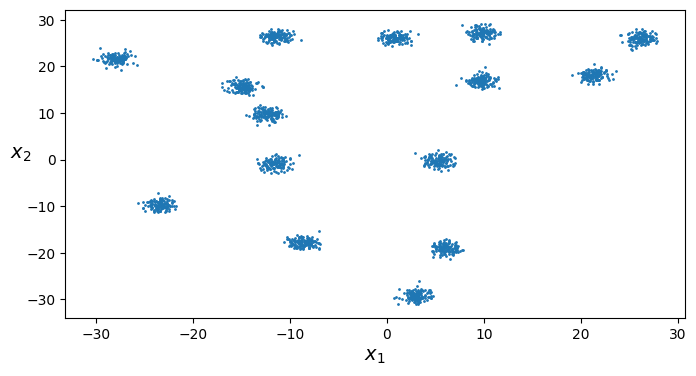

In [4]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [5]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([11,  9,  0, ..., 10,  9,  8], dtype=int32)

In [6]:
kmeans.cluster_centers_

array([[ 26.18675753,  25.99445064],
       [-11.56551725,  -0.90100762],
       [-11.40189149,  26.3987663 ],
       [  6.03625949, -18.98083738],
       [  9.67783139,  16.88681667],
       [ -8.6743925 , -17.79521044],
       [  5.2685092 ,  -0.23158486],
       [-27.93955012,  21.62052257],
       [-24.14562643, -10.01110781],
       [-13.62494034,  12.70329943],
       [  0.79418143,  26.11185794],
       [  2.98381491, -29.22486715],
       [ 21.31342533,  18.1399935 ],
       [  9.83263233,  27.1615094 ],
       [-23.01576618,  -9.51609126]])

In [7]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([6, 6, 6, 6], dtype=int32)

In [8]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

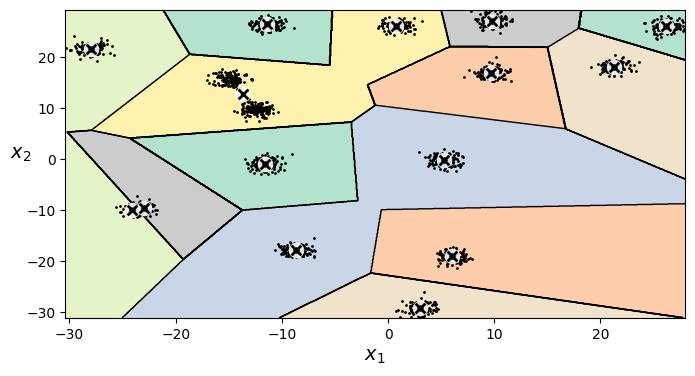

In [9]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

In [10]:
kmeans.transform(X_new)

array([[35.51731875, 11.92380118, 26.93144865, 21.83190248, 17.75606181,
        21.61239093,  5.72163964, 34.14064099, 26.96809201, 17.32626959,
        24.12493353, 31.36710825, 26.73502364, 27.01448156, 25.73608072],
       [33.36704042, 14.85160389, 28.33221268, 21.19939643, 16.31596588,
        22.98133583,  3.18215414, 36.63632989, 29.68420026, 19.77243688,
        24.21254487, 31.22487134, 24.41067261, 26.07271409, 28.45066692],
       [37.15658186,  9.41201074, 24.86149723, 23.76575683, 18.803486  ,
        21.55549831,  8.87757766, 31.12402643, 24.82793675, 14.38900195,
        23.42122521, 32.7757243 , 28.64196317, 27.35790542, 23.60685147],
       [37.46806675,  9.21601533, 25.33264319, 23.30408462, 19.17571127,
        21.07354496,  8.70803079, 31.42571469, 24.56960186, 14.73080706,
        23.91475796, 32.28425679, 28.90937647, 27.80047659, 23.34560655]])

In [11]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=15, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=15, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=15, n_init=1, random_state=5)


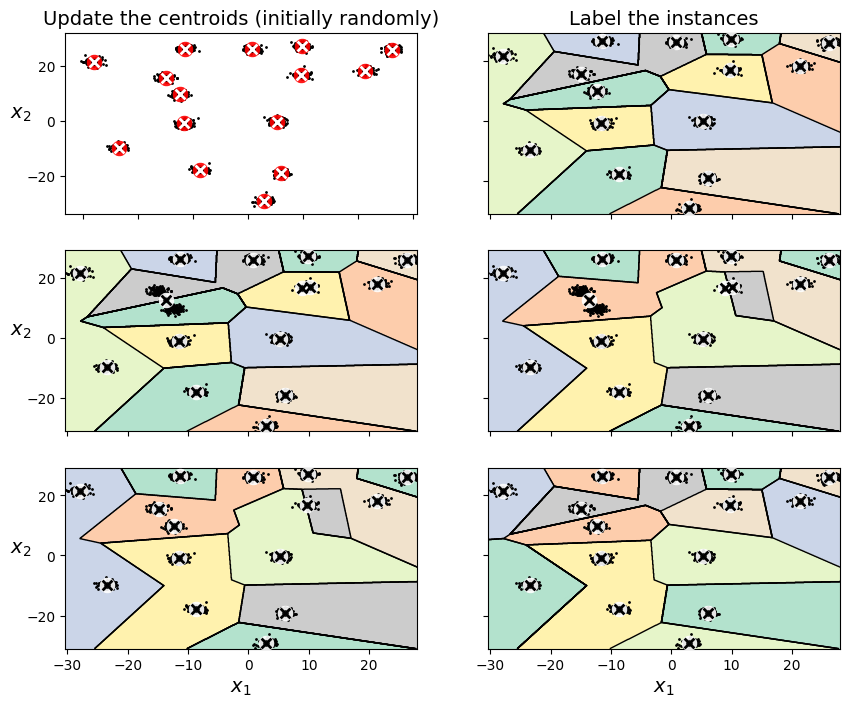

In [12]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

In [13]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)
    plt.figure(figsize=(10, 3.2))
    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)
    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

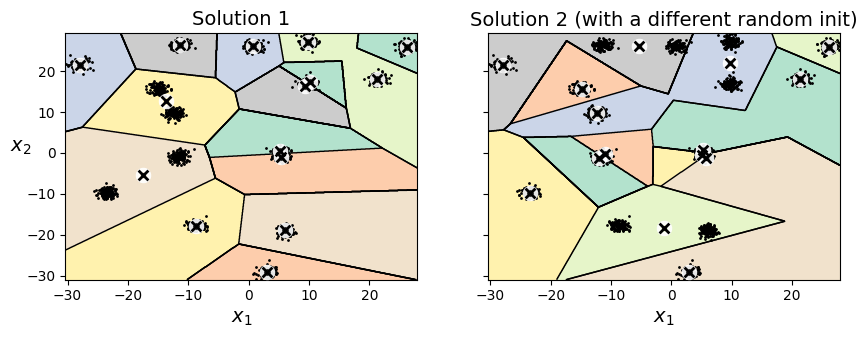

In [14]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1", "Solution 2 (with a different random init)")
plt.show()

In [15]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=15, n_init=10,
       random_state=11)


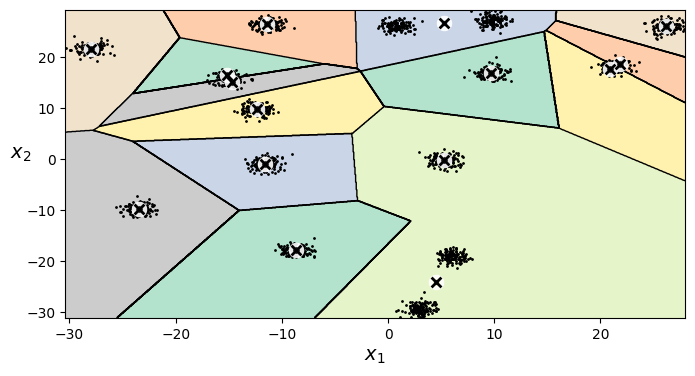

In [16]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [17]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [18]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [19]:
best_kmeans.score(X)

-155918.61849332455

In [20]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.8038016485407611)

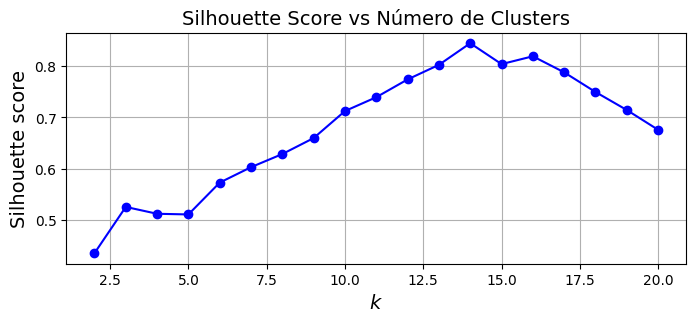

In [21]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers)+5)
# el + a len(...) es para poder ver en la gráfica que llega a su pico y luego baja
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

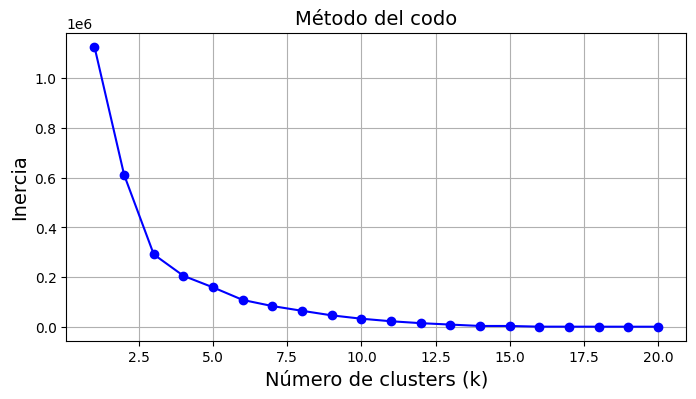

In [22]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

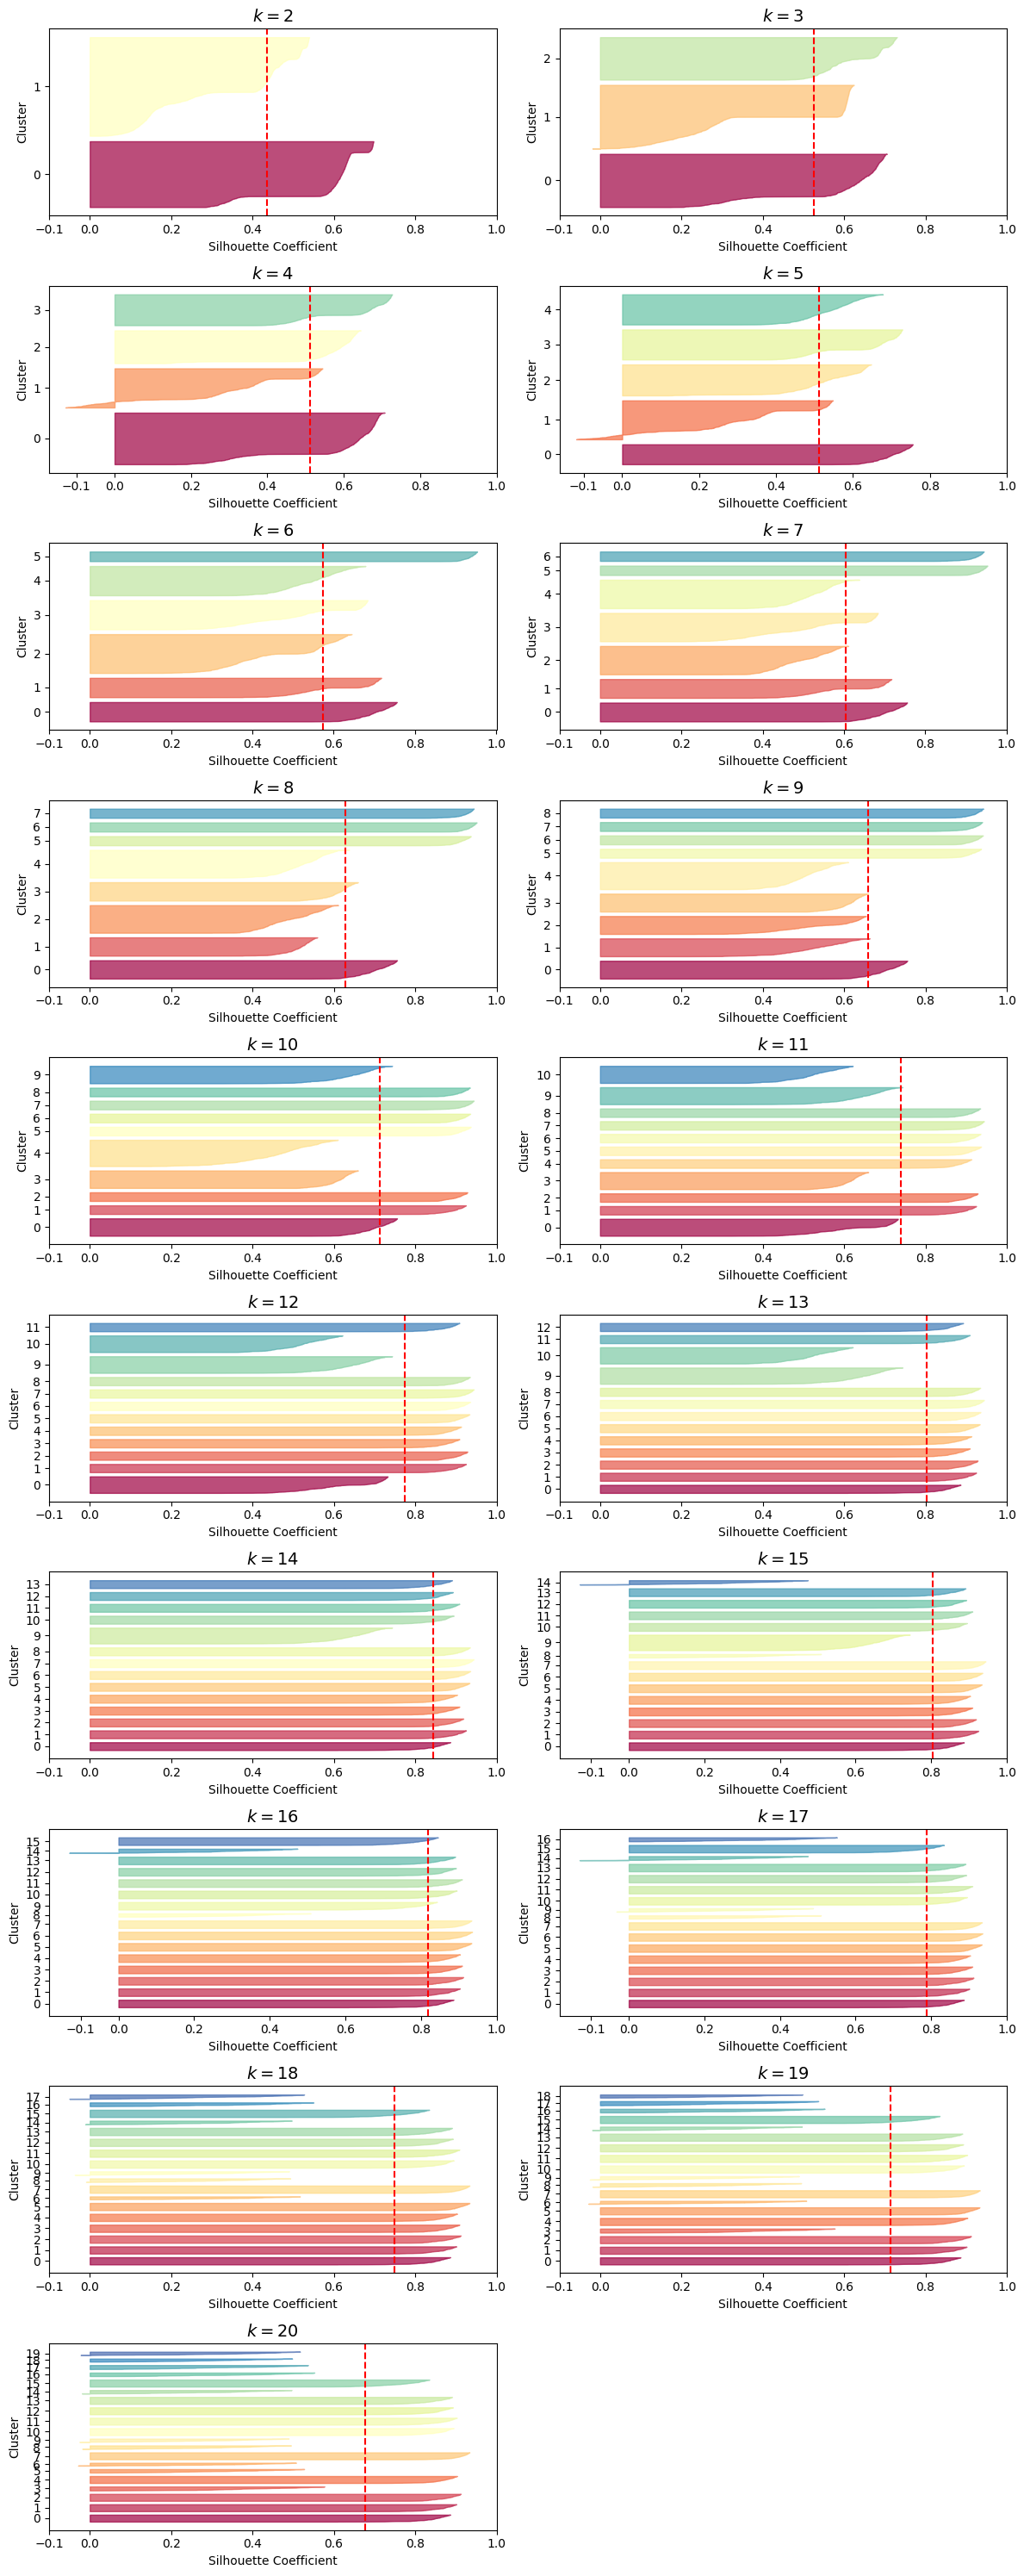

In [23]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


**Trabajo con el dataset**

In [24]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "/content/drive/MyDrive/ia/marketing_sample_for_amazon_com-ecommerce__20200101_20200131__10k_data.csv"
)

print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras filas:")
df.head()

Mounted at /content/drive
Dimensiones del dataset:
(10002, 28)

Columnas:
['Uniq Id', 'Product Name', 'Brand Name', 'Asin', 'Category', 'Upc Ean Code', 'List Price', 'Selling Price', 'Quantity', 'Model Number', 'About Product', 'Product Specification', 'Technical Details', 'Shipping Weight', 'Product Dimensions', 'Image', 'Variants', 'Sku', 'Product Url', 'Stock', 'Product Details', 'Dimensions', 'Color', 'Ingredients', 'Direction To Use', 'Is Amazon Seller', 'Size Quantity Variant', 'Product Description']

Primeras filas:


,Uniq Id,Product Name,Brand Name,Asin,Category,Upc Ean Code,List Price,Selling Price,Quantity,Model Number,...,Product Url,Stock,Product Details,Dimensions,Color,Ingredients,Direction To Use,Is Amazon Seller,Size Quantity Variant,Product Description
0,4c69b61db1fc16e7013b43fc926e502d,"DB Longboards CoreFlex Crossbow 41"" Bamboo Fib...",NaN,NaN,Sports & Outdoors | Outdoor Recreation | Skate...,NaN,NaN,$237.68,NaN,NaN,...,https://www.amazon.com/DB-Longboards-CoreFlex-...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
1,66d49bbed043f5be260fa9f7fbff5957,"Electronic Snap Circuits Mini Kits Classpack, ...",NaN,NaN,Toys & Games | Learning & Education | Science ...,NaN,NaN,$99.95,NaN,55324,...,https://www.amazon.com/Electronic-Circuits-Cla...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
2,2c55cae269aebf53838484b0d7dd931a,3Doodler Create Flexy 3D Printing Filament Ref...,NaN,NaN,Toys & Games | Arts & Crafts | Craft Kits,NaN,NaN,$34.99,NaN,NaN,...,https://www.amazon.com/3Doodler-Plastic-Innova...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
3,18018b6bc416dab347b1b7db79994afa,Guillow Airplane Design Studio with Travel Cas...,NaN,NaN,Toys & Games | Hobbies | Models & Model Kits |...,NaN,NaN,$28.91,NaN,142,...,https://www.amazon.com/Guillow-Airplane-Design...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN
4,e04b990e95bf73bbe6a3fa09785d7cd0,Woodstock- Collage 500 pc Puzzle,NaN,NaN,Toys & Games | Puzzles | Jigsaw Puzzles,NaN,NaN,$17.49,NaN,62151,...,https://www.amazon.com/Woodstock-Collage-500-p...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN


In [25]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nTipos de datos:")
print(df.dtypes)

Valores nulos por columna:
Uniq Id                      0
Product Name                 0
Brand Name               10002
Asin                     10002
Category                   830
Upc Ean Code              9968
List Price               10002
Selling Price              107
Quantity                 10002
Model Number              1772
About Product              273
Product Specification     1632
Technical Details          790
Shipping Weight           1138
Product Dimensions        9523
Image                        0
Variants                  7524
Sku                      10002
Product Url                  0
Stock                    10002
Product Details          10002
Dimensions               10002
Color                    10002
Ingredients              10002
Direction To Use         10002
Is Amazon Seller             0
Size Quantity Variant    10002
Product Description      10002
dtype: int64

Tipos de datos:
Uniq Id                   object
Product Name              object
Brand Nam

In [26]:
# Columnas con 10002 nulos (completamente vacías) o casi vacías
columnas_eliminar = [
    'Brand Name', 'Asin', 'List Price', 'Quantity', 'Sku',
    'Stock', 'Product Details', 'Dimensions', 'Color',
    'Ingredients', 'Direction To Use', 'Size Quantity Variant',
    'Product Description', 'Upc Ean Code', 'Product Dimensions',
    'Variants', 'Uniq Id', 'Product Url'
]

df = df.drop(columns=columnas_eliminar)

print("Columnas restantes:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

Columnas restantes:
['Product Name', 'Category', 'Selling Price', 'Model Number', 'About Product', 'Product Specification', 'Technical Details', 'Shipping Weight', 'Image', 'Is Amazon Seller']

Shape: (10002, 10)


In [27]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/ia/imagenes_amazon"
os.makedirs(SAVE_DIR, exist_ok=True)

primera_imagen = df['Image'].str.split('|').str[0].str.strip()

imagenes = []
indices_ok = []

for i, url in enumerate(primera_imagen):
    try:
        resp = requests.get(url, timeout=5)
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        img = img.resize((28, 28))
        imagenes.append(np.array(img))
        indices_ok.append(i)
    except:
        pass

    if i % 500 == 0:
        print(f"{i}/{len(primera_imagen)} | Descargadas: {len(imagenes)}")

X_imagenes = np.array(imagenes)
print(f"Shape final: {X_imagenes.shape}")

0/10002 | Descargadas: 1
500/10002 | Descargadas: 499
1000/10002 | Descargadas: 998
1500/10002 | Descargadas: 1496
2000/10002 | Descargadas: 1996
2500/10002 | Descargadas: 2495
3000/10002 | Descargadas: 2994
3500/10002 | Descargadas: 3493
4000/10002 | Descargadas: 3991
4500/10002 | Descargadas: 4491
5000/10002 | Descargadas: 4990
5500/10002 | Descargadas: 5488
6000/10002 | Descargadas: 5986
6500/10002 | Descargadas: 6484
7000/10002 | Descargadas: 6981
7500/10002 | Descargadas: 7477
8000/10002 | Descargadas: 7974
8500/10002 | Descargadas: 8470
9000/10002 | Descargadas: 8968
9500/10002 | Descargadas: 9466
10000/10002 | Descargadas: 9964
Shape final: (9965, 28, 28, 3)


In [28]:
# Selling Price: quitar $ y convertir a número
df['Selling Price'] = df['Selling Price'].str.replace('$', '', regex=False)
df['Selling Price'] = df['Selling Price'].str.replace(',', '', regex=False)
df['Selling Price'] = pd.to_numeric(df['Selling Price'], errors='coerce')

# Is Amazon Seller: Y/N a número
df['Is Amazon Seller'] = df['Is Amazon Seller'].map({'Y': 1, 'N': 0})

print("Tipos después de conversión:")
print(df.dtypes)
print(f"\nNulos restantes:")
print(df.isnull().sum())

Tipos después de conversión:
Product Name              object
Category                  object
Selling Price            float64
Model Number              object
About Product             object
Product Specification     object
Technical Details         object
Shipping Weight           object
Image                     object
Is Amazon Seller           int64
dtype: object

Nulos restantes:
Product Name                0
Category                  830
Selling Price             492
Model Number             1772
About Product             273
Product Specification    1632
Technical Details         790
Shipping Weight          1138
Image                       0
Is Amazon Seller            0
dtype: int64


In [29]:
# Numéricos: interpolación lineal
df['Selling Price'] = df['Selling Price'].interpolate(method='linear')
df['Is Amazon Seller'] = df['Is Amazon Seller'].interpolate(method='linear').round()

# Texto: rellenar con string vacío
df['Category'] = df['Category'].fillna('Unknown')
df['About Product'] = df['About Product'].fillna('')
df['Product Specification'] = df['Product Specification'].fillna('')
df['Technical Details'] = df['Technical Details'].fillna('')
df['Shipping Weight'] = df['Shipping Weight'].fillna('')
df['Model Number'] = df['Model Number'].fillna('Unknown')

print("Nulos después de interpolación:")
print(df.isnull().sum())

Nulos después de interpolación:
Product Name             0
Category                 0
Selling Price            0
Model Number             0
About Product            0
Product Specification    0
Technical Details        0
Shipping Weight          0
Image                    0
Is Amazon Seller         0
dtype: int64


In [31]:
# Alinear df con las imágenes descargadas
df_clean = df.iloc[indices_ok].reset_index(drop=True)

# Aplanar imágenes igual que bloodmnist
X_train_full = X_imagenes.reshape(len(X_imagenes), -1)  # (9965, 2352)

# Categoría principal como etiqueta
df_clean['category_main'] = df_clean['Category'].str.split('|').str[0].str.strip()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_full = le.fit_transform(df_clean['category_main']).astype(np.int64)

# Split igual que el cuadernillo
X_train_full_split, X_test, y_train_full_split, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_split, y_train_full_split, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(f"Clases: {le.classes_}")

X_train shape: (6377, 2352)
y_train shape: (6377,)
X_val shape: (1595, 2352)
X_test shape: (1993, 2352)
y_test shape: (1993,)
Clases: ['Arts, Crafts & Sewing' 'Automotive' 'Baby Products'
 'Beauty & Personal Care' 'Cell Phones & Accessories'
 'Clothing, Shoes & Jewelry' 'Electronics' 'Grocery & Gourmet Food'
 'Health & Household' 'Hobbies' 'Home & Kitchen' 'Industrial & Scientific'
 'Movies & TV' 'Musical Instruments' 'Office Products'
 'Patio, Lawn & Garden' 'Pet Supplies'
 'Remote & App Controlled Vehicle Parts'
 'Remote & App Controlled Vehicles & Parts' 'Sports & Outdoors'
 'Tools & Home Improvement' 'Toys & Games' 'Unknown' 'Video Games']


In [32]:
from sklearn.cluster import KMeans

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

In [33]:
print(X_digits_dist.shape)
print(X_digits_dist)

(6377, 50)
[[4132.14059044 4167.92971502 4239.78975181 ... 4739.74018034
  4034.4198867  4263.71455678]
 [2499.7968527  4035.06087637 3912.96443712 ... 3772.71887935
  4176.5539018  2813.79189382]
 [2869.87979188 3652.53330378 3191.33914099 ... 3797.46380951
  2466.3428555  2992.7962276 ]
 ...
 [2368.56435696 3844.53596849 3409.67599724 ... 3553.49613127
  3266.02789357 2841.67617519]
 [6691.38929007 5376.36232848 4842.84753214 ... 5627.24520695
  4981.70500464 7059.94978587]
 [3606.62256129 3461.46136957 3352.64101362 ... 3804.74573727
  3786.20825631 3832.86686076]]


In [34]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]


In [35]:
print(X_representative_digits.shape)
print(X_representative_digits)

(50, 2352)
[[255 255 255 ... 255 255 255]
 [222 205 187 ... 195 139  95]
 [246 246 247 ... 241 242 244]
 ...
 [246 246 247 ... 241 242 244]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


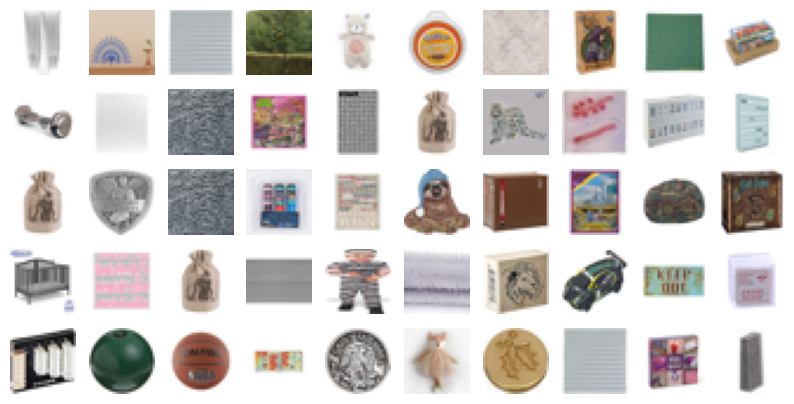

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(28, 28, 3))
    plt.axis('off')
plt.show()

In [37]:
y_representative_digits = y_train[idxs]

In [38]:
from sklearn.linear_model import LogisticRegression


log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1.17 s, sys: 829 µs, total: 1.17 s
Wall time: 852 ms


0.43000501756146514

In [39]:
idxs = np.random.choice(len(X_train), 50, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs], y_train[idxs])
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 660 ms, sys: 3.85 ms, total: 663 ms
Wall time: 538 ms


0.5494229804315103

In [40]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
  y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [41]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 36.6 s, sys: 21.5 ms, total: 36.6 s
Wall time: 35.3 s


0.4234821876567988

In [42]:
#Aprendizaje Activo begins
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.99911062, 0.99934124, 0.99936775, 0.99953072, 0.99953587,
       0.99974411, 0.99976006, 0.99976318, 0.99977694, 0.99977792])

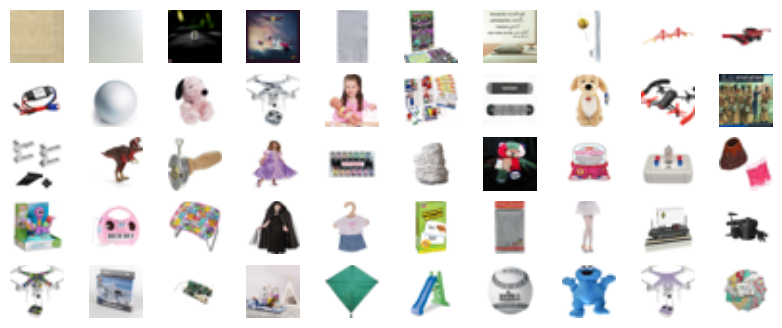

In [43]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(28, 28,3), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

In [44]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([22, 10,  5, 22, 21, 21,  2, 19, 21, 21,  9, 21, 21, 21, 22, 21, 19,
       21, 21, 22,  1, 21, 22, 21,  0, 21, 22, 21, 21, 21, 21, 21, 21,  5,
       21, 21, 10, 21, 21, 10, 21, 21, 21, 10, 21, 21, 19, 22, 21, 22])

In [45]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [46]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 32.2 s, sys: 35.5 ms, total: 32.2 s
Wall time: 30.7 s


0.44706472654290014